In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
seq_pd = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/algebraic_starscape_runs/sequential_alg.csv")
par_2_pd = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/algebraic_starscape_runs/par_2_alg.csv")
par_4_pd = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/algebraic_starscape_runs/par_4_alg.csv")
par_8_pd = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/algebraic_starscape_runs/par_8_alg.csv")
par_16_pd = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/algebraic_starscape_runs/par_16_alg.csv")
par_32_pd = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/algebraic_starscape_runs/par_32_alg.csv")

gpu_ea_pd = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/algebraic_starscape_runs/gpu_alg_4_ea.csv")
gpu_dk_pd = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/algebraic_starscape_runs/gpu_alg_4_dk.csv")


In [3]:
def compute_speedup(seq_pd, new_pd):
    out = np.array(seq_pd["timing"])/np.array(new_pd["timing"])

    return out

def compute_gpu_speedup(seq_pd, new_pd):
    unique_degs = np.unique(new_pd["degree"])

    speedup = []

    for k in unique_degs:
        val_seq = seq_pd[seq_pd["degree"] == k]["timing"].to_list()[0]
        val_gpu = new_pd[new_pd["degree"] == k]["timing"].to_list()[0]

        speedup.append(val_seq/val_gpu)

    return speedup, unique_degs


In [4]:
p2_speedup = compute_speedup(seq_pd, par_2_pd)
p4_speedup = compute_speedup(seq_pd, par_4_pd)
p8_speedup = compute_speedup(seq_pd, par_8_pd)
p16_speedup = compute_speedup(seq_pd, par_16_pd)
p32_speedup = compute_speedup(seq_pd, par_32_pd)

In [5]:
gpu_ea, degs_ea = compute_gpu_speedup(seq_pd, gpu_ea_pd)
gpu_dk, degs_dk = compute_gpu_speedup(seq_pd, gpu_dk_pd)

total_values = gpu_ea + gpu_dk
total_degs = list(degs_ea) + list(degs_dk)
labels = (len(gpu_ea)*["EA"]) + (len(gpu_dk)*["DK"])

In [6]:
degs_dk

array([2, 3, 4])

In [7]:
len(total_degs)

6

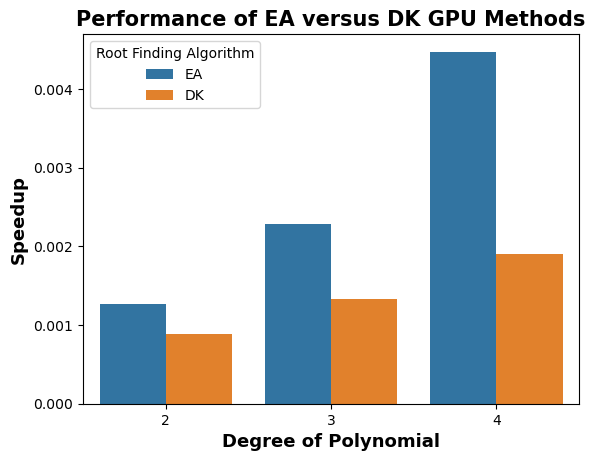

In [8]:
sns.barplot(x = total_degs, y = total_values, hue = labels)
plt.title("Performance of EA versus DK GPU Methods", weight = "bold", size = 15)
plt.xlabel("Degree of Polynomial", weight = "bold", size = 13)
plt.ylabel("Speedup", weight = "bold", size = 13)
plt.legend(title = "Root Finding Algorithm")

Text(0, 0.5, 'Speedup')

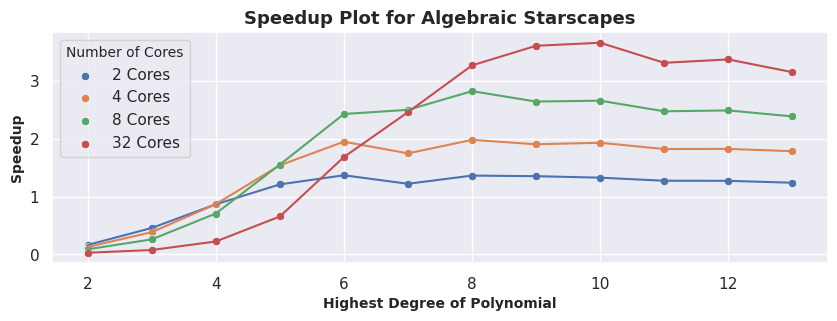

In [9]:
sns.set_theme()

fig, ax = plt.subplots(figsize = (10 ,3))

sns.scatterplot(seq_pd, ax = ax, x = seq_pd["degree"], y = p2_speedup, label = "2 Cores")
sns.scatterplot(seq_pd, ax = ax, x = seq_pd["degree"], y = p4_speedup, label = "4 Cores")
sns.scatterplot(seq_pd, ax = ax, x = seq_pd["degree"], y = p8_speedup, label = "8 Cores")
sns.scatterplot(seq_pd, ax = ax, x = seq_pd["degree"], y = p32_speedup, label = "32 Cores")

sns.lineplot(seq_pd, ax = ax, x = seq_pd["degree"], y = p2_speedup, legend = False)
sns.lineplot(seq_pd, ax = ax, x = seq_pd["degree"], y = p4_speedup, legend = False)
sns.lineplot(seq_pd, ax = ax, x = seq_pd["degree"], y = p8_speedup, legend = False)
sns.lineplot(seq_pd, ax = ax, x = seq_pd["degree"], y = p32_speedup,legend = False)
plt.legend(title = "Number of Cores", title_fontsize=10)
plt.title("Speedup Plot for Algebraic Starscapes", weight = "bold", size = 13)
plt.xlabel("Highest Degree of Polynomial", weight = "bold", size = 10)
plt.ylabel("Speedup", weight = "bold", size = 10)


In [14]:
root_seq_pd = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/algebraic_starscape_runs/sequential_alg_roots.csv")

In [15]:
root_seq_pd

,Unnamed: 0,timing,degree,number_of_roots_found
0,0,0.000416,10,8
1,1,0.000293,20,18
2,2,0.000425,30,28
3,3,0.000626,40,38
4,4,0.000904,50,48
...,...,...,...,...
144,144,5.987060,1450,1448
145,145,5.695907,1460,1458
146,146,5.640351,1470,1468
147,147,5.862566,1480,1478


In [16]:
timing_for_root_finding_ea = pd.read_csv("/home/jbauer/code/hp_mathematics/timing_results/algebraic_starscape_runs/gpu_alg_4_ea_large_rts.csv")

In [17]:
speedup_in_finding_roots = np.array(root_seq_pd["timing"].to_list())/np.array(timing_for_root_finding_ea["timing"].to_list())

Text(0.5, 1.0, 'Speedup of Root Finding Algorithm')

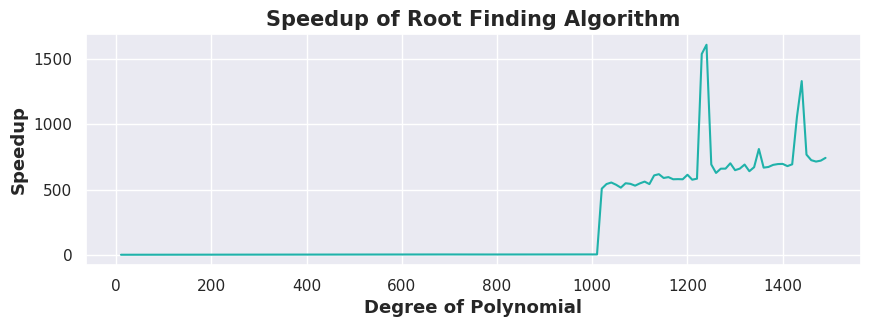

In [28]:
sns.set_theme()
fig, ax = plt.subplots(figsize=(10, 3))
sns.lineplot(x = root_seq_pd["degree"], y = speedup_in_finding_roots, color = "lightseagreen")
plt.xlabel("Degree of Polynomial", weight = "bold", size = 13)
plt.ylabel("Speedup", weight = "bold", size = 13)
plt.title("Speedup of Root Finding Algorithm", weight = "bold", size = 15)